# Strategic Classification: No-Poisoning Reference

Runs RGD and PerfGD on the credit dataset across all valid (classifier, performativity) combinations.

**Classifiers:** LogReg, MLP

**Performativity models:**
- **Linear:** `x'_S = x_S - alpha * theta_S` (logreg only)
- **Matrix:** `x'_S = x_S - alpha * A @ theta_S` (logreg only)
- **Elementwise:** `x'_S = x_S - alpha * g(theta_S)` (logreg only, default g=tanh)
- **Gradient:** `x'_S = x_S - alpha * grad_x_S P(y=1|x)` (any classifier)

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

cwd = os.getcwd()  # poison-perf/strategic/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from utils.strategic_setup import setup_strategic_classification
from data_prep import load_data

## Load Data

In [18]:
data_dir = "data/GiveMeSomeCredit"
data_file = "cs-training.csv"
data_path = os.path.join(root, data_dir, data_file)
X_np, Y_np, data = load_data(data_path)

n_samples, d_plus_bias = X_np.shape
print("n_samples =", n_samples, ", d+1 (with bias) =", d_plus_bias)

strat_features = np.array([1, 6, 8]) - 1  # 0-indexed
print("\nStrategic features:")
for i, feature in enumerate(strat_features):
    print(f"  {i}: [{feature}] {data.columns[feature + 1]}")

device = torch.device("cpu")
X_full = torch.from_numpy(X_np).float().to(device)
Y_full = torch.from_numpy(Y_np).float().to(device)

lam = 1.0 / n_samples
alpha_strat = 1.0

n_samples = 18357 , d+1 (with bias) = 11

Strategic features:
  0: [0] RevolvingUtilizationOfUnsecuredLines
  1: [5] NumberOfOpenCreditLinesAndLoans
  2: [7] NumberRealEstateLoansOrLines


## Hyperparameters and Experiment Definitions

In [19]:
n = n_samples
max_iter = 30

# Smoothness-based learning rate (for logreg)
smoothness = (X_full ** 2).sum().item() / (4.0 * n_samples)
eta_logreg = 2.0 / (smoothness + 2.0 * lam)
eta_mlp = 0.01  # MLP needs smaller, fixed learning rate

proj_theta = lambda t: t

# Response matrix for "matrix" performativity: diagonal with per-feature manipulation costs
# RevolvingUtilization (easy), OpenCreditLines (moderate), RealEstateLoans (hard)
A_matrix = torch.diag(torch.tensor([1.5, 1.0, 0.5], dtype=torch.float32))

MLP_HIDDEN_DIMS = [32, 16]

experiments = [
    {"name": "LogReg + Linear",       "classifier": "logreg", "performativity": "linear",      "eta": eta_logreg},
    {"name": "LogReg + Matrix",        "classifier": "logreg", "performativity": "matrix",      "eta": eta_logreg, "response_matrix": A_matrix},
    {"name": "LogReg + Elementwise",   "classifier": "logreg", "performativity": "elementwise", "eta": eta_logreg},
    {"name": "LogReg + Gradient",      "classifier": "logreg", "performativity": "gradient",    "eta": eta_logreg},
    {"name": "MLP + Gradient",         "classifier": "mlp",    "performativity": "gradient",    "eta": eta_mlp, "hidden_dims": MLP_HIDDEN_DIMS},
]

print(f"eta_logreg = {eta_logreg:.4f}, eta_mlp = {eta_mlp}")
print(f"A_matrix =\n{A_matrix}")
print(f"\nExperiments ({len(experiments)}):")
for e in experiments:
    print(f"  {e['name']}")

eta_logreg = 0.4286, eta_mlp = 0.01
A_matrix =
tensor([[1.5000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.5000]])

Experiments (5):
  LogReg + Linear
  LogReg + Matrix
  LogReg + Elementwise
  LogReg + Gradient
  MLP + Gradient


## Run All Experiments (RGD + PerfGD)

In [20]:
results = {}

for exp in experiments:
    name = exp["name"]
    eta = exp["eta"]
    print(f"\n{'='*60}")
    print(f"Running: {name} (eta={eta:.4f})")
    print(f"{'='*60}")

    # Build setup kwargs (exclude name and eta)
    setup_kwargs = {
        "X_base": X_full,
        "Y_base": Y_full,
        "strat_features": strat_features.tolist(),
        "alpha": alpha_strat,
        "lam": lam,
        "perfGD": True,
        "classifier": exp["classifier"],
        "performativity": exp["performativity"],
    }
    if "hidden_dims" in exp:
        setup_kwargs["hidden_dims"] = exp["hidden_dims"]
    if "response_matrix" in exp:
        setup_kwargs["response_matrix"] = exp["response_matrix"]

    mu_f, sigma, D_theta, loss_fn, theta_0, grad2_est, f_hat = \
        setup_strategic_classification(**setup_kwargs)

    print(f"  theta_0: {theta_0.shape} ({theta_0.numel()} params)")

    # RGD
    print("  Running RGD...", end=" ")
    theta_rgd, all_theta_rgd, all_losses_rgd = RGD(
        D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
    )
    print(f"final loss = {all_losses_rgd[-1]:.4f}")

    # PerfGD
    print("  Running PerfGD...", end=" ")
    theta_perfgd, all_theta_perfgd, all_losses_perfgd = PerfGD(
        f_hat=f_hat, grad2_est=grad2_est, D_theta=D_theta, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True,
    )
    print(f"final loss = {all_losses_perfgd[-1]:.4f}")

    results[name] = {
        "rgd_losses": all_losses_rgd,
        "perfgd_losses": all_losses_perfgd,
        "rgd_theta": theta_rgd.detach(),
        "perfgd_theta": theta_perfgd.detach(),
        "rgd_norms": [t.norm().item() for t in all_theta_rgd],
        "perfgd_norms": [t.norm().item() for t in all_theta_perfgd],
    }

print("\nDone.")


Running: LogReg + Linear (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6199
  Running PerfGD... final loss = 0.6242

Running: LogReg + Matrix (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6197
  Running PerfGD... final loss = 0.6237

Running: LogReg + Elementwise (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6199
  Running PerfGD... final loss = 0.6240

Running: LogReg + Gradient (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6200
  Running PerfGD... final loss = 0.6175

Running: MLP + Gradient (eta=0.0100)
  theta_0: torch.Size([897]) (897 params)
  Running RGD... final loss = 0.6811
  Running PerfGD... final loss = 0.6803

Done.


## RGD Loss Curves

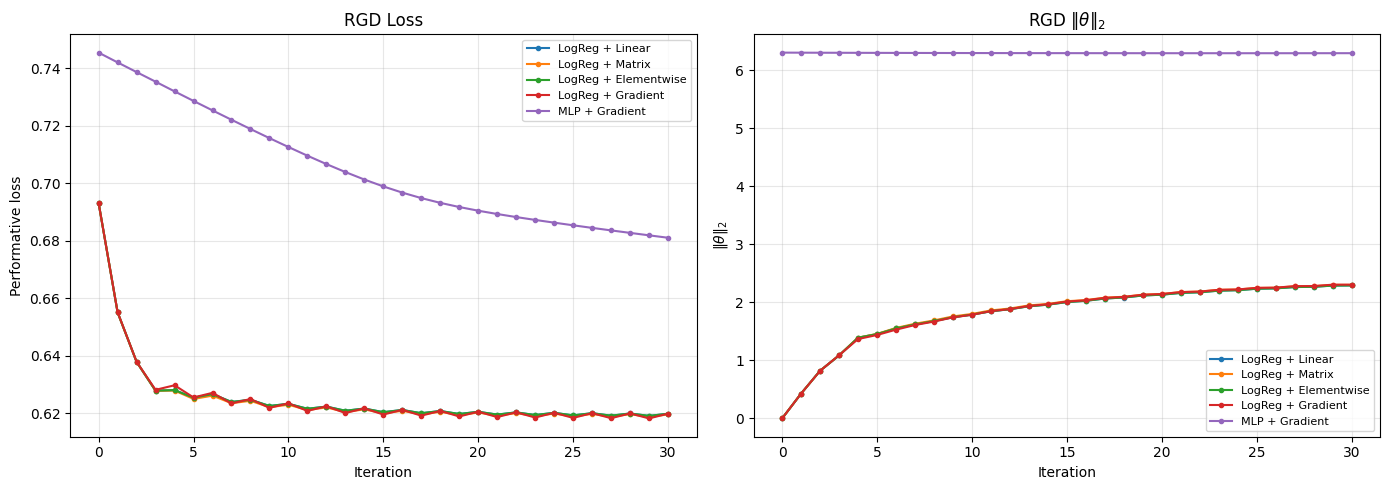

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    ax1.plot(res["rgd_losses"], marker="o", markersize=3, label=name)
    ax2.plot(res["rgd_norms"], marker="o", markersize=3, label=name)

ax1.set_xlabel("Iteration")
ax1.set_ylabel("Performative loss")
ax1.set_title("RGD Loss")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$\|\theta\|_2$")
ax2.set_title(r"RGD $\|\theta\|_2$")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PerfGD Loss Curves

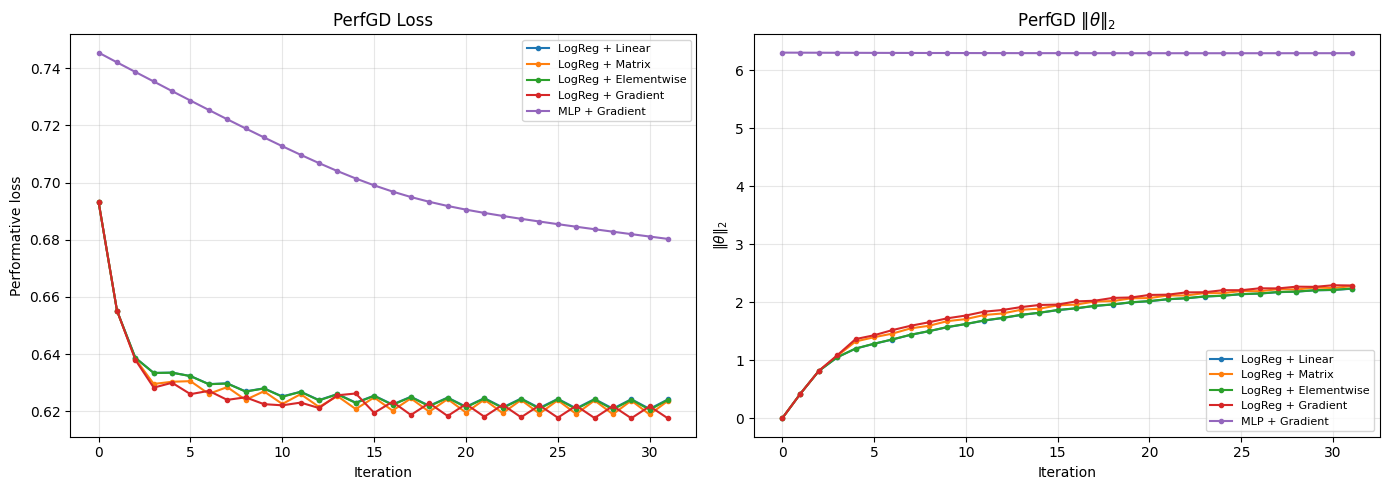

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    ax1.plot(res["perfgd_losses"], marker="o", markersize=3, label=name)
    ax2.plot(res["perfgd_norms"], marker="o", markersize=3, label=name)

ax1.set_xlabel("Iteration")
ax1.set_ylabel("Performative loss")
ax1.set_title("PerfGD Loss")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$\|\theta\|_2$")
ax2.set_title(r"PerfGD $\|\theta\|_2$")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## RGD vs PerfGD per Experiment

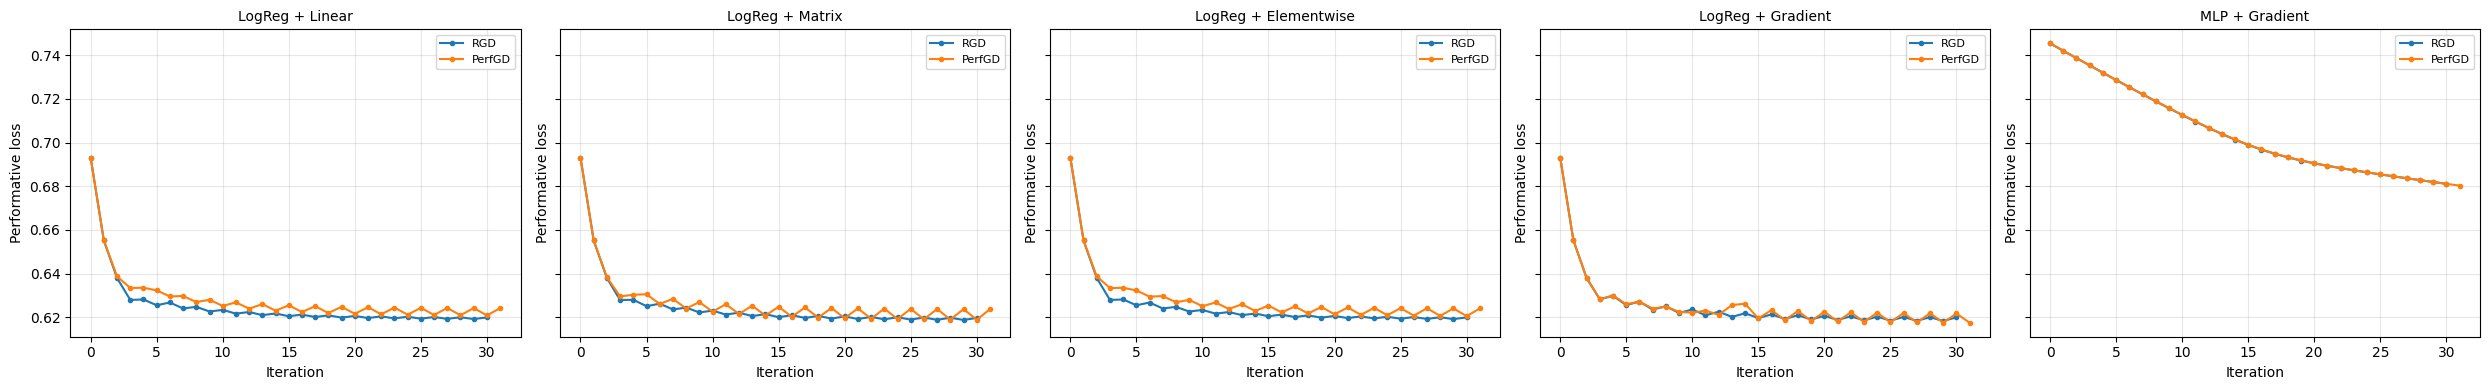

In [23]:
n_exp = len(results)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4), sharey=True)
if n_exp == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    ax.plot(res["rgd_losses"], marker="o", markersize=3, label="RGD", color="tab:blue")
    ax.plot(res["perfgd_losses"], marker="o", markersize=3, label="PerfGD", color="tab:orange")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Performative loss")
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Table

In [24]:
print(f"{'Experiment':<25} {'RGD final':>12} {'PerfGD final':>14} {'RGD ||th||_2':>14} {'PerfGD ||th||_2':>16}")
print("-" * 85)
for name, res in results.items():
    print(f"{name:<25} {res['rgd_losses'][-1]:>12.4f} {res['perfgd_losses'][-1]:>14.4f} "
          f"{res['rgd_norms'][-1]:>14.4f} {res['perfgd_norms'][-1]:>16.4f}")

Experiment                   RGD final   PerfGD final   RGD ||th||_2  PerfGD ||th||_2
-------------------------------------------------------------------------------------
LogReg + Linear                 0.6199         0.6242         2.2932           2.2359
LogReg + Matrix                 0.6197         0.6237         2.3034           2.2813
LogReg + Elementwise            0.6199         0.6240         2.2935           2.2391
LogReg + Gradient               0.6200         0.6175         2.3063           2.2922
MLP + Gradient                  0.6811         0.6803         6.2981           6.2982
